In [1]:
%matplotlib inline
import kwant
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import tinyarray
from scipy import constants
import warnings
warnings.filterwarnings('ignore')

# Verificar versión de kwant (opcional)
print("Kwant version:", kwant.__version__)

Kwant version: 1.5.0


En este caso se tiene que el halmintoniano al cual se quiere simular es equivalente a: 

 $H(Ψ)=D₁∇⁴Ψ+D₂∇²Ψ+ ϵΨ= iħ ∂Ψ/∂t$

Que al usar kwant, lo que buscamos es usar el modelo tight-binding real del grafeno, es decir escribirlo bajo el halmintonino estandar   

$$H = -t \sum_{\langle i,j\rangle} c_i^\dagger c_j$$

Para lo cual es necesario discretizar el operador diferencial sobre la red. Dado a que el hamiltoniano original contiene terminos a la cuarta, el modelo resultante incluirá tanto saltos entre primeros vecinos como terminos de sitio (on-site) y posibles saltos a distancias mayores.

Parámetros iniciales: Discretización del espacio real $\longrightarrow$ En una red con espaciado $a$ (distancia entre primeros vecinos), las derivadas se aproximan a diferencias finitas. Para el laplaciano: 

$$\nabla^2 \Psi(\mathbf{r}) \approx \frac{1}{a^2} \sum_{\boldsymbol{\delta}} \bigl[ \Psi(\mathbf{r}+\boldsymbol{\delta}) - \Psi(\mathbf{r}) \bigr],$$

donde la suma recorre todos los vectores $\boldsymbol{\delta}$ que conectan un sitio con sus primeros vecinos. El bi-laplaciano se obtiene aplicando el laplaciano dos veces:

$$ \nabla^4 \Psi = \nabla^2(\nabla^2 \Psi) \approx \frac{1}{a^4} \sum_{\boldsymbol{\delta},\boldsymbol{\delta}'} \bigl[ \Psi(\mathbf{r}+\boldsymbol{\delta}+\boldsymbol{\delta}') - 2\Psi(\mathbf{r}+\boldsymbol{\delta}) + \Psi(\mathbf{r}) \bigr] + \text{términos cruzados}$$

Al sustituir estas aproximaciones en $H\Psi$, se obtiene una expresión del tipo

$$H\Psi(\mathbf{r}) = \sum_{\mathbf{r}'} h(\mathbf{r},\mathbf{r}')\, \Psi(\mathbf{r}'),$$

donde $h(\mathbf{r},\mathbf{r}')$ representa la amplitud de salto desde $(\mathbf{r}')$ a $(\mathbf{r})$. En segunda cuantización, esto equivale a


$$H = \sum_{i} \varepsilon_i \, c_i^\dagger c_i + \sum_{\langle i,j \rangle} t_{ij} \, c_i^\dagger c_j + \sum_{\langle\!\langle i,j \rangle\!\rangle} t_{ij}^{(2)} \, c_i^\dagger c_j + \cdots,$$

con $\varepsilon_i$ la energía de sitio y $t_{ij}^{(n)}$ los saltos a vecinos de orden $n$. Los términos concretos dependen de la geometría de la red.



$$H = \sum_i \varepsilon_0\, c_i^\dagger c_i - t_1 \sum_{\langle i,j \rangle} c_i^\dagger c_j - t_2 \sum_{\langle\!\langle i,j \rangle\!\rangle} c_i^\dagger c_j,$$

Usando la literatura de Mikhail I. Katsnelson, Graphene: carbon in two dimensions, existe una alternativa más sencilla de trabajar en el espacio de momentos, en primer lugar el Hamiltoniano continuo es diagonal en ondas planas (Zettili)

$$H(k) = D_1 k^4 + D_2 k^2 + \epsilon$$

Para una red periodica, el tight-binding produce una relación de dispersión $E(\mathbf{k})$. La idea general es igualar a $E(\mathbf{k})$ con la expresiòn continua para valores muy pequeños de $k$ (expansion de onda larga) esto permite determinar los parámetros del modelo discreto.

Para la red hexagonal del rGO, la relación de dispersión con solo primeros vecinos es

$$E_{\pm}(\mathbf{k}) = \pm t \sqrt{3 + 2\cos(\mathbf{k}\cdot\mathbf{a}_1) + 2\cos(\mathbf{k}\cdot\mathbf{a}_2) + 2\cos(\mathbf{k}\cdot(\mathbf{a}_1-\mathbf{a}_2))}$$

donde $\mathbf{a}_1$, $\mathbf{a}_2$ son los vectores de la red. Cerca del punto $\Gamma$ y $\mathbf{k}=0$ se expanden como

$$E_{\pm}(\mathbf{k}) \approx \pm 3t \left(1 - \frac{a^2}{4}k^2 + \frac{a^4}{64}k^4 + \cdots\right)$$

que es una expresión par en $k$ (sin término lineal). Sin embargo, el Hamiltoniano continuo dado tiene un término de sitio dado por $\epsilon$ y no tiene estructura de bandas simétricas $pm$; más bien representa una única banda con curvatura. Esto sugiere que el modelo continuo describe electrones en una banda de conducción o valencia con una masa efectiva, posiblemente debido a la presencia de una brecha o a efectos de curvatura en el rGO.

Para obtener una banda parabólica con corrección $k^4$ a partir de un tight‑binding, se necesitan incluir: Un potencial on‑site $\varepsilon_0$, saltos a primeros vecinos $t_1$ (que dan la curvatura) y saltos a segundos vecinos $t_2$ (que modifican el término $k^4$).

En una red hexagonal, la expansión hasta $k^4$ alrededor de $\Gamma$ (tomando solo la banda inferior) es

$$E(k) \approx \varepsilon_0 + 3t_1 + 6t_2 - \frac{3t_1 a^2}{4} k^2 + \frac{3t_1 a^4}{64} \left(1 - \frac{16t_2}{t_1}\right) k^4 + \cdots$$

donde se tiene presente que $a$ es la distancia carbono a carbono $\approx 1.42Å$. Luego comparando con

$$H(k) = \epsilon + D_2 k^2 + D_1 k^4$$

es posible deducir:
$$
\begin{aligned}
\epsilon_0 + 3t_1 + 6t_2 &= \epsilon,\\[4pt]
-\frac{3t_1 a^2}{4} &= D_2,\\[4pt]
\frac{3t_1 a^4}{64}\left(1 - \frac{16t_2}{t_1}\right) &= D_1.
\end{aligned}
$$

A partir de $D_2$ y $a$ se obtiene $t_1$; luego con $D_1$ y $t_1$ se obtiene $t_2$; finalmente $\epsilon_0$ se ajusta para reproducir $\epsilon$

Usando la data con la que se cuenta: En la nueva rama
Usaremos a  $D₁ = -0.976eV$, $D₂ = 2.370eV$ (la curvatura es negativa) y $ϵ = 0.146eV$

Usamos la distancia $a = 1.42Å = 1.42\times10^{-10}m$, convertimos las unidades a eV·Å² para $D_2$

$ D_2 = 2.370 \text{eV} \quad \Rightarrow \quad D_2 \text{ en eV Å}^2$: ya está en $eV$, pero necesitamos $k^2$ con $k$ en $Å^{-1}$.

La ecuacion de ajuste es equivalente a

$$t_1 = -\frac{4 D_2}{3 a^2}$$

$$t_1 = -\frac{4 \times 2.370}{3 \times 2.0164} \approx -\frac{9.48}{6.0492} \approx -1.567\ \text{eV}$$

El signo negativo indica que, según la convención $H = -t\sum c_i^\dagger c_j$, el salto efectivo sería $t \approx 1.567$ eV, próximo al valor estándar de 2.7 eV pero algo menor. La discrepancia puede deberse a que el modelo continuo no describe exactamente el grafeno prístino, sino un rGO con modificaciones.

A continuación, de la ecuación para $D_1$:

$$D_1 = \frac{3 t_1 a^4}{64}\left(1 - \frac{16 t_2}{t_1}\right)$$

Con $D_1 = -0.976 eV$, $t_1 \approx -1.567 eV$, $a^4 \approx (2.0164)^2 \approx 4.066Å⁴$:

$$ \frac{3 t_1 a^4}{64} = \frac{3 \times (-1.567) \times 4.066}{64} = \frac{-19.11}{64} \approx -0.2986 \text{eV Å⁴}$$

Se tiene presente que el valor de $a^4$ está en $Å⁴$, es decir se debe tener preucaciones, pero $k^4$ en la expansión debe tener unidades consistentes. Si usamos $k$ en $Å⁻¹$, $D_1$ debe estar en $eV·Å⁴$. Nuestro $D_1 = -0.976$ eV ya está en eV, pero en realidad la expresión $D_1 k^4$ requiere que $D_1$ tenga unidades de energía × longitud⁴. Por lo tanto, el valor dado $-0.976 eV$ debe interpretarse como el coeficiente cuando $k$ se mide en $Å⁻¹$, es decir, $D_1 = -0.976 eV·Å⁴$. Esto es razonable.

Entonces:

$$-0.976 = -0.2986 \left(1 - \frac{16 t_2}{t_1}\right) \quad \Rightarrow \quad 1 - \frac{16 t_2}{t_1} = \frac{0.976}{0.2986} \approx 3.268$$

Por lo tanto:

$$-\frac{16 t_2}{t_1} = 2.268 \quad \Rightarrow \quad \frac{t_2}{t_1} = -\frac{2.268}{16} \approx -0.14175$$

Con $t_1 \approx -1.567 eV$:

$$t_2 = -0.14175 \times (-1.567) \approx 0.222\ \text{eV}$$

Finalmente, la energía on‑site $\varepsilon_0$ se obtiene de la ecuación constante:

$$
\begin{align*}
   \varepsilon_0 + 3t_1 + 6t_2 = \epsilon\\[4pt]
   \varepsilon_0 + 3(-1.567) + 6(0.222) = 0.146\\[4pt]
   \varepsilon_0 -4.701 + 1.332 = 0.146 \quad \Rightarrow \quad \varepsilon_0 -3.369 = 0.146\\[4pt]
   \varepsilon_0 = 3.515\ \text{eV}
\end{align*}
$$

Con los parámetros obtenidos, el halmintoniano discreto que reproduce (en aproximación de onda larga) el continuo dado es:
 
$$H = \sum_i \varepsilon_0\, c_i^\dagger c_i - t_1 \sum_{\langle i,j \rangle} c_i^\dagger c_j - t_2 \sum_{\langle\!\langle i,j \rangle\!\rangle} c_i^\dagger c_j$$

donde:

- $t_1 \approx 1.567 eV$ Aquí salto a primeros vecinos, notar que el signo se absorbe en la definición: $H = -t\sum c_i^\dagger c_j$ implica $t = -t_1$ positivo si $t_1$ negativo; en este caso $t_1$ negativo da $t = 1.567 eV$.
- $t_2 \approx 0.222 eV$ interpretado como salto a segundos vecinos.
- $\varepsilon_0 \approx 3.515 eV$ (energía de sitio).

Lo ideal es mantener la forma estrictamente estándar es decir solo con primeros vecinos y sin término on‑site, entonces la conversión no es exacta porque el continuo contiene términos de curvatura superior y un desplazamiento constante. En este caso, el mejor ajuste es tomar $t \approx 1.567 eV$ e ignorar el resto, pero se perdería precisión.

Constantes Fisicas

In [2]:
# Parámetros del grafeno prístino
a_graphene = 0.246  # nm
t1 = 1.567          # eV - primeros vecinos
t2 = 0.222          # eV - segundos vecinos
epsilon_0 = 3.515   # eV - energía on-site

# Parámetros del rGO (defectos)
W_disorder = 0.5    # eV - ancho desorden Anderson
epsilon_O = 0.8     # eV - energía adicional por oxígeno
concentration_O = 0.10  # 10% sitios con oxígeno

# Funciones de trabajo
phi_Au = 5.1        # eV
phi_Pd = 5.6        # eV
phi_graphene = 4.5  # eV

# Acoplamiento interfacial
t_Au_interface = 0.15   # eV
t_Pd_interface = 0.80   # eV

# Matrices de Pauli (para spin, si se usa)
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

Funciones Auxiliares de análisis

In [3]:
def calcular_estructura_bandas(lead, momenta=None):
    if momenta is None:
        momenta = np.linspace(-np.pi, np.pi, 201)
    bands = kwant.physics.Bands(lead)
    energies = np.array([bands(k) for k in momenta])
    return momenta, energies

def calcular_transmision(syst, energies):
    print("Calculando transmisión...")
    transmissions = []
    for i, E in enumerate(energies):
        try:
            smatrix = kwant.smatrix(syst, energy=E)
            T = smatrix.transmission(1, 0)
            transmissions.append(T)
        except Exception as e:
            transmissions.append(0)
        if (i+1) % 10 == 0:
            print(f"  Progreso: {i+1}/{len(energies)}")
    print("✓ Transmisión calculada")
    return np.array(transmissions)

def calcular_DOS(syst, energies):
    """
    Calcula la densidad de estados (DOS) promediada sobre todos los sitios.
    """
    print("Calculando DOS...")
    dos_values = []
    for i, E in enumerate(energies):
        try:
            # greens_function devuelve un objeto con método density()
            # density() devuelve un array con LDOS por sitio
            ldos = kwant.greens_function(syst, energy=E).density()
            # Promediamos sobre todos los sitios para obtener un escalar
            dos = np.mean(ldos)
            dos_values.append(dos)
        except Exception:
            dos_values.append(0)
        if (i+1) % 10 == 0:
            print(f"  Progreso: {i+1}/{len(energies)}")
    print("✓ DOS calculada")
    return np.array(dos_values)

def calcular_resistencia(transmision):
    """Calcula resistencia de contacto en kOhms."""
    h = constants.h
    e = constants.e
    R_quantum = h / (2 * e**2)  # Ohms
    T_safe = np.where(transmision > 1e-6, transmision, 1e-6)
    R = R_quantum / T_safe
    return R * 1e-3  # kOhms

Función para construir rGO (Sin SOC por ahora)

In [4]:
def construir_sistema(metal_type='Au', include_disorder=True, include_oxygen=True, L=30, W=15):
    """
    Construye sistema de grafeno con leads metálicos.
    Retorna: syst, lat, lead_left, lead_right
    """
    print(f"\nConstruyendo sistema con {metal_type}...")
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    a, b = lat.sublattices

    syst = kwant.Builder()

    def shape_graphene(pos):
        x, y = pos
        return 0 <= x <= L and 0 <= y <= W

    # On-site energies iniciales
    syst[lat.shape(shape_graphene, (L/2, W/2))] = epsilon_0

    # Hoppings
    syst[lat.neighbors()] = -t1
    syst[a.neighbors()] = -t2
    syst[b.neighbors()] = -t2

    # Desorden Anderson
    if include_disorder:
        rng = np.random.RandomState(42)
        for site in syst.sites():
            disorder = W_disorder * (rng.random() - 0.5)
            syst[site] = syst[site] + disorder

    # Oxígeno adsorbido
    if include_oxygen:
        print(f"Agregando oxígeno adsorbido ({concentration_O*100:.1f}% de sitios)...")
        rng_O = np.random.RandomState(123)
        sites_list = list(syst.sites())
        n_oxygen = int(len(sites_list) * concentration_O)
        oxygen_indices = rng_O.choice(len(sites_list), n_oxygen, replace=False)
        oxygen_sites = [sites_list[i] for i in oxygen_indices]
        
        for site in oxygen_sites:
            current_onsite = syst[site]
            if include_SOC:
                delta_O = epsilon_O * sigma_0 + 0.05 * sigma_z
                syst[site] = current_onsite + delta_O
            else:
                syst[site] = current_onsite + epsilon_O

    # Construcción de leads
    phi_metal = phi_Au if metal_type == 'Au' else phi_Pd
    t_interface = t_Au_interface if metal_type == 'Au' else t_Pd_interface
    barrier_height = phi_metal - phi_graphene
    onsite_metal = epsilon_0 + barrier_height
    hop_metal = -t_interface

    def shape_lead(pos):
        x, y = pos
        return 0 <= y <= W

    sym_left = kwant.TranslationalSymmetry(lat.vec((-1, 0)))
    lead_left = kwant.Builder(sym_left)
    lead_left[lat.shape(shape_lead, (0, W/2))] = onsite_metal
    lead_left[lat.neighbors()] = hop_metal

    sym_right = kwant.TranslationalSymmetry(lat.vec((1, 0)))
    lead_right = kwant.Builder(sym_right)
    lead_right[lat.shape(shape_lead, (0, W/2))] = onsite_metal
    lead_right[lat.neighbors()] = hop_metal

    syst.attach_lead(lead_left)
    syst.attach_lead(lead_right)

    print(f"  Sitios totales: {len(list(syst.sites()))}")
    print(f"  Barrera Schottky: {barrier_height:.3f} eV")
    print(f"  t_interface: {t_interface:.3f} eV")
    return syst, lat, lead_left, lead_right

Construir Au y Pd pequeños para pruebas rápidas

In [5]:
# --- Dimensiones y opciones ---
L = 10
W = 5
include_disorder = True
include_oxygen = True
include_SOC = False
metal_type = 'Au'
# reducir para pruebas rápidas
energias = epsilon_0 + np.linspace(-2, 2, 31)  # menos puntos

print("--- Sistema con Oro (Au) ---")
syst_Au, lat, lead_left_Au, lead_right_Au = construir_sistema('Au', L=L, W=W)
syst_Au_fin = syst_Au.finalized()
lead_left_Au_fin = lead_left_Au.finalized()

print("\n--- Sistema con Paladio (Pd) ---")
syst_Pd, _, lead_left_Pd, lead_right_Pd = construir_sistema('Pd', L=L, W=W)
syst_Pd_fin = syst_Pd.finalized()
lead_left_Pd_fin = lead_left_Pd.finalized()

--- Sistema con Oro (Au) ---

Construyendo sistema con Au...
Agregando oxígeno adsorbido (10.0% de sitios)...
  Sitios totales: 2444
  Barrera Schottky: 0.600 eV
  t_interface: 0.150 eV

--- Sistema con Paladio (Pd) ---

Construyendo sistema con Pd...
Agregando oxígeno adsorbido (10.0% de sitios)...
  Sitios totales: 2444
  Barrera Schottky: 1.100 eV
  t_interface: 0.800 eV


Construir bandas de los Leads

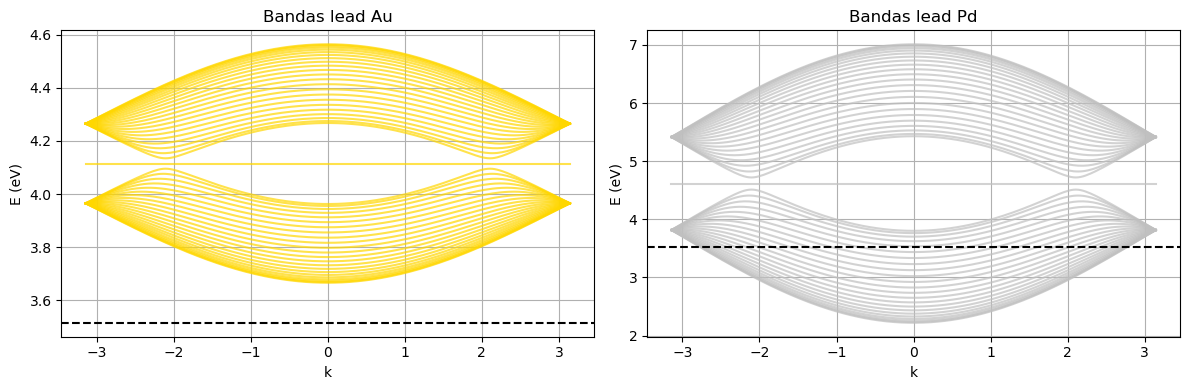

In [6]:
k, bands_Au = calcular_estructura_bandas(lead_left_Au_fin)
k, bands_Pd = calcular_estructura_bandas(lead_left_Pd_fin)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for band in bands_Au.T:
    plt.plot(k, band, 'gold', alpha=0.7)
plt.axhline(epsilon_0, color='k', ls='--')
plt.title('Bandas lead Au')
plt.xlabel('k')
plt.ylabel('E (eV)')
plt.grid(True)

plt.subplot(1,2,2)
for band in bands_Pd.T:
    plt.plot(k, band, 'silver', alpha=0.7)
plt.axhline(epsilon_0, color='k', ls='--')
plt.title('Bandas lead Pd')
plt.xlabel('k')
plt.ylabel('E (eV)')
plt.grid(True)
plt.tight_layout()
plt.show()

Calcular Transmisión y Dos para Au y Pd

In [7]:
print("\n--- Calculando Au ---")
trans_Au = calcular_transmision(syst_Au_fin, energias)
dos_Au = calcular_DOS(syst_Au_fin, energias)

print("\n--- Calculando Pd ---")
trans_Pd = calcular_transmision(syst_Pd_fin, energias)
dos_Pd = calcular_DOS(syst_Pd_fin, energias)


--- Calculando Au ---
Calculando transmisión...
  Progreso: 10/31
  Progreso: 20/31
  Progreso: 30/31
✓ Transmisión calculada
Calculando DOS...
  Progreso: 10/31
  Progreso: 20/31
  Progreso: 30/31
✓ DOS calculada

--- Calculando Pd ---
Calculando transmisión...
  Progreso: 10/31
  Progreso: 20/31
  Progreso: 30/31
✓ Transmisión calculada
Calculando DOS...
  Progreso: 10/31
  Progreso: 20/31
  Progreso: 30/31
✓ DOS calculada


Graficar transmisión y DOS comparativa

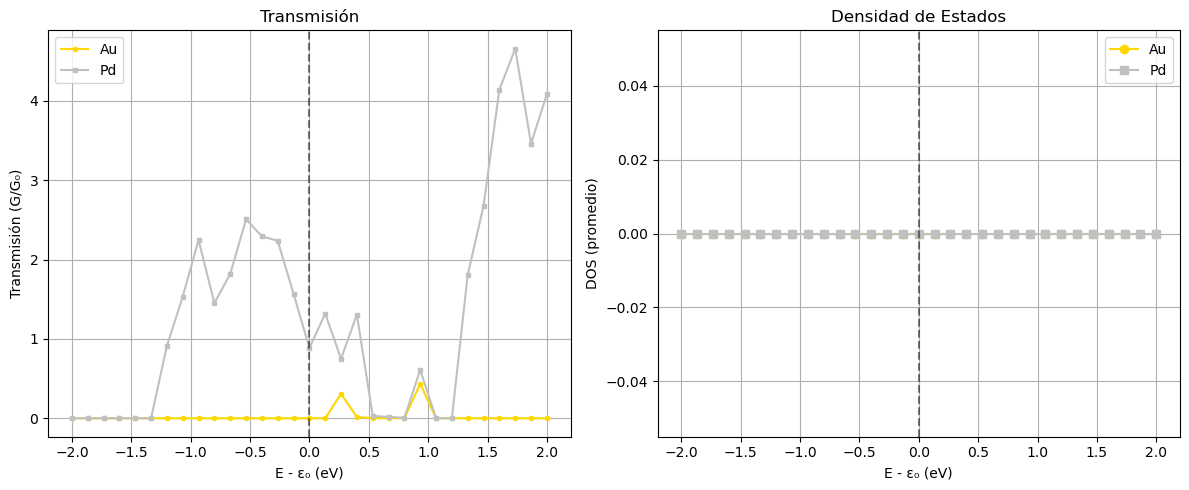

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.plot(energias - epsilon_0, trans_Au, 'o-', color='gold', label='Au', markersize=3)
ax1.plot(energias - epsilon_0, trans_Pd, 's-', color='silver', label='Pd', markersize=3)
ax1.axvline(0, color='k', ls='--', alpha=0.5)
ax1.set_xlabel('E - ε₀ (eV)')
ax1.set_ylabel('Transmisión (G/G₀)')
ax1.set_title('Transmisión')
ax1.legend()
ax1.grid(True)

ax2.plot(energias - epsilon_0, dos_Au, 'o-', color='gold', label='Au')
ax2.plot(energias - epsilon_0, dos_Pd, 's-', color='silver', label='Pd')
ax2.axvline(0, color='k', ls='--', alpha=0.5)
ax2.set_xlabel('E - ε₀ (eV)')
ax2.set_ylabel('DOS (promedio)')
ax2.set_title('Densidad de Estados')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Resistencia de Contacto

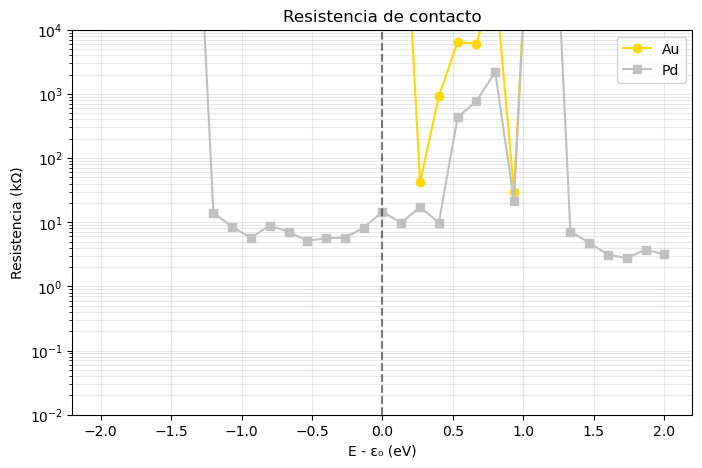

In [9]:
R_Au = calcular_resistencia(trans_Au)
R_Pd = calcular_resistencia(trans_Pd)

plt.figure(figsize=(8,5))
plt.semilogy(energias - epsilon_0, R_Au, 'o-', color='gold', label='Au')
plt.semilogy(energias - epsilon_0, R_Pd, 's-', color='silver', label='Pd')
plt.axvline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('E - ε₀ (eV)')
plt.ylabel('Resistencia (kΩ)')
plt.title('Resistencia de contacto')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.ylim(1e-2, 1e4)
plt.show()

Función para analizar estados de borde (LDOS)

In [10]:
def analyze_edge_states(syst, energies):
    """Analiza LDOS en bordes vs centro de una nanocinta."""
    syst_final = syst.finalized()
    # Obtener sitios y posiciones
    sites = list(syst_final.sites)   # ¡ojo: sin paréntesis!
    positions = np.array([site.pos for site in sites])

    y_min, y_max = positions[:,1].min(), positions[:,1].max()
    tol = 0.5
    edge_bottom = [i for i, pos in enumerate(positions) if pos[1] < y_min + tol]
    edge_top    = [i for i, pos in enumerate(positions) if pos[1] > y_max - tol]
    center = [i for i, pos in enumerate(positions) if abs(pos[1] - (y_min+y_max)/2) < 1.0]

    ldos_edge = []
    ldos_center = []
    for E in energies:
        try:
            # Calcular LDOS usando kwant.ldos (más simple)
            ldos_all = kwant.ldos(syst_final, energy=E)
            # Promediar en cada región
            if edge_bottom:
                ldos_edge.append(np.mean(ldos_all[edge_bottom]))
            else:
                ldos_edge.append(0)
            if center:
                ldos_center.append(np.mean(ldos_all[center]))
            else:
                ldos_center.append(0)
        except Exception:
            ldos_edge.append(0)
            ldos_center.append(0)
    return np.array(ldos_edge), np.array(ldos_center)

Construcción de Nanocinta zigzag y analisis de estados de borde

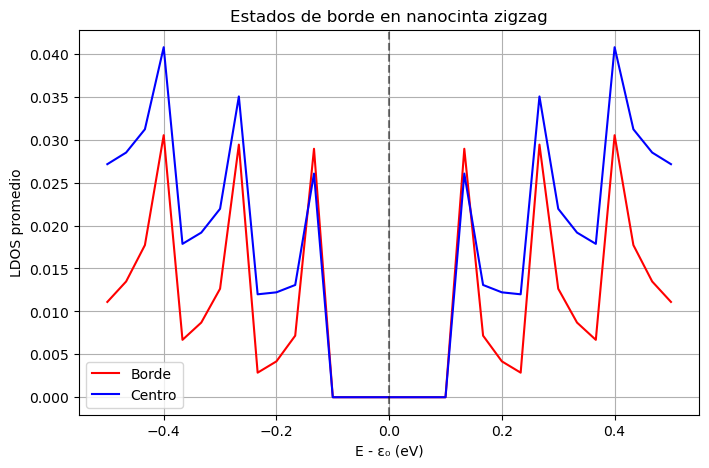

In [11]:
def make_zigzag_ribbon(L, W):
    """Crea una nanocinta de grafeno con bordes zigzag."""
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    syst = kwant.Builder()

    def shape(pos):
        x, y = pos
        return 0 <= y <= W and 0 <= x <= L

    syst[lat.shape(shape, (L/2, W/2))] = epsilon_0
    syst[lat.neighbors()] = -t1
    # leads
    sym = kwant.TranslationalSymmetry(lat.vec((1,0)))
    lead = kwant.Builder(sym)
    def lead_shape(pos):
        x, y = pos
        return 0 <= y <= W
    lead[lat.shape(lead_shape, (0, W/2))] = epsilon_0
    lead[lat.neighbors()] = -t1
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst

# Crear nanocinta pequeña
L_ribbon, W_ribbon = 20, 8
syst_zz = make_zigzag_ribbon(L_ribbon, W_ribbon)
energies_zz = epsilon_0 + np.linspace(-0.5, 0.5, 31)
ldos_edge, ldos_center = analyze_edge_states(syst_zz, energies_zz)

plt.figure(figsize=(8,5))
plt.plot(energies_zz - epsilon_0, ldos_edge, 'r-', label='Borde')
plt.plot(energies_zz - epsilon_0, ldos_center, 'b-', label='Centro')
plt.axvline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('E - ε₀ (eV)')
plt.ylabel('LDOS promedio')
plt.title('Estados de borde en nanocinta zigzag')
plt.legend()
plt.grid(True)
plt.show()

Visualizar la estructura de la nanocinta

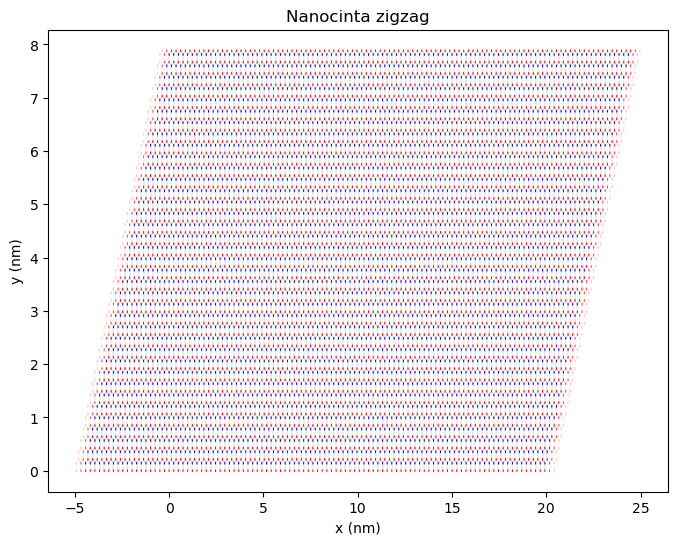

In [12]:
# Tomamos la familia (subred) del primer sitio como referencia para la subred A
subred_A = list(syst_zz.sites())[0].family

def site_color(site):
    return 'red' if site.family == subred_A else 'blue'

# Graficar
fig, ax = plt.subplots(figsize=(8,6))
kwant.plot(syst_zz, site_size=0.2, site_color=site_color, hop_lw=0.05, ax=ax)
ax.set_title("Nanocinta zigzag")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
plt.show()

Función para analizar localización (Participation Ratio)

  Desorden W=0.0 eV
  Desorden W=0.5 eV
  Desorden W=1.0 eV


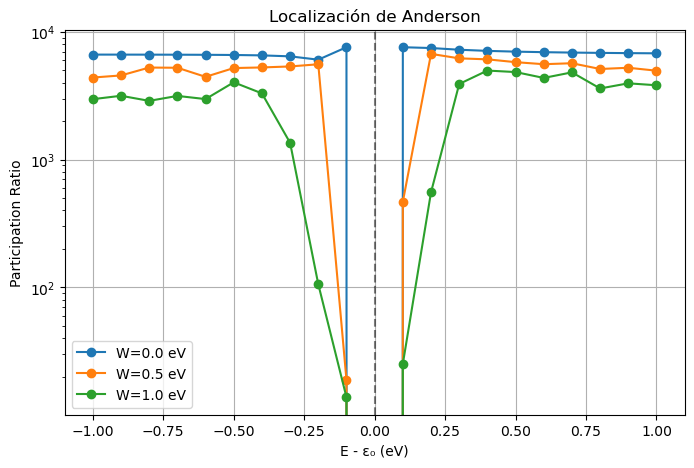

In [13]:
def calculate_participation_ratio(wavefunction):
    psi2 = np.abs(wavefunction)**2
    return np.sum(psi2)**2 / (np.sum(psi2**2) + 1e-12)

def analyze_localization(L, W, disorder_strengths, energies):
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    results = {}
    for Wd in disorder_strengths:
        print(f"  Desorden W={Wd} eV")
        syst = kwant.Builder()
        def shape(pos):
            x, y = pos
            return 0 <= x <= L and 0 <= y <= W
        
        # CORRECCIÓN: Primero llenamos todo el sistema, luego iteramos
        syst[lat.shape(shape, (L/2, W/2))] = epsilon_0
        rng = np.random.RandomState(42)
        
        for site in syst.sites():
            disorder = Wd * (rng.random() - 0.5)
            syst[site] += disorder
            
        syst[lat.neighbors()] = -t1
        
        # leads sin desorden
        sym = kwant.TranslationalSymmetry(lat.vec((1,0)))
        lead = kwant.Builder(sym)
        def lead_shape(pos):
            x, y = pos
            return 0 <= y <= W
        lead[lat.shape(lead_shape, (0, W/2))] = epsilon_0
        lead[lat.neighbors()] = -t1
        syst.attach_lead(lead)
        syst.attach_lead(lead.reversed())
        syst_fin = syst.finalized()
        
        pr_list = []
        for E in energies:
            try:
                wf = kwant.wave_function(syst_fin, energy=E)
                psi = wf(0)[0] 
                pr = calculate_participation_ratio(psi)
                pr_list.append(pr)
            except:
                pr_list.append(0)
        results[Wd] = np.array(pr_list)
    return results

# Prueba rápida
disorders = [0.0, 0.5, 1.0]
energies_loc = epsilon_0 + np.linspace(-1, 1, 21)
loc_results = analyze_localization(L=20, W=10, disorder_strengths=disorders, energies=energies_loc)

plt.figure(figsize=(8,5))
for Wd, pr in loc_results.items():
    plt.plot(energies_loc - epsilon_0, pr, 'o-', label=f'W={Wd} eV')
plt.axvline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('E - ε₀ (eV)')
plt.ylabel('Participation Ratio')
plt.yscale('log')
plt.title('Localización de Anderson')
plt.legend()
plt.grid(True)
plt.show()

 Efecto del oxígeno en transmisión

Conc. O = 0%
Conc. O = 5%
Conc. O = 10%
Conc. O = 15%


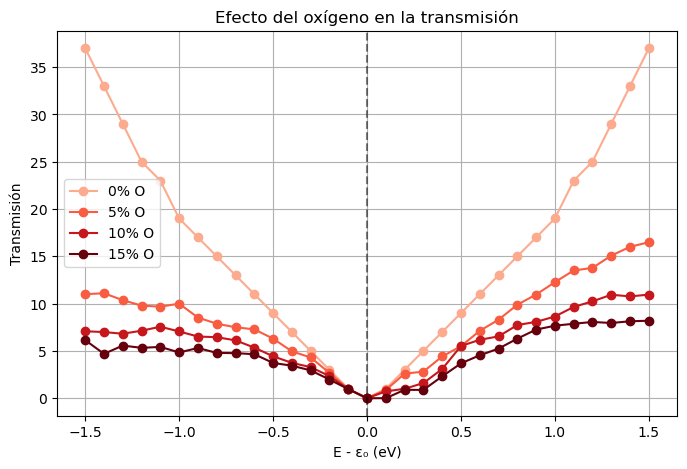

In [14]:
def oxigeno_dependence(L, W, conc_list, energies):
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    results = {}
    for conc in conc_list:
        print(f"Conc. O = {conc*100:.0f}%")
        syst = kwant.Builder()
        def shape(pos):
            x, y = pos
            return 0 <= x <= L and 0 <= y <= W
        
        # CORRECCIÓN: Llenado masivo primero
        syst[lat.shape(shape, (L/2, W/2))] = epsilon_0
        syst[lat.neighbors()] = -t1
        
        # Obtener lista de sitios para seleccionar aleatoriamente
        sites_list = list(syst.sites())
        rng = np.random.RandomState(123)
        n_oxy = int(len(sites_list) * conc)
        
        # Elegir índices para evitar errores de NumPy
        oxy_indices = rng.choice(len(sites_list), n_oxy, replace=False)
        for i in oxy_indices:
            syst[sites_list[i]] += epsilon_O
            
        # Leads
        sym = kwant.TranslationalSymmetry(lat.vec((1,0)))
        lead = kwant.Builder(sym)
        def lead_shape(pos):
            x, y = pos
            return 0 <= y <= W
        lead[lat.shape(lead_shape, (0, W/2))] = epsilon_0
        lead[lat.neighbors()] = -t1
        syst.attach_lead(lead)
        syst.attach_lead(lead.reversed())
        syst_fin = syst.finalized()
        
        trans = []
        for E in energies:
            try:
                sm = kwant.smatrix(syst_fin, energy=E)
                trans.append(sm.transmission(1,0))
            except:
                trans.append(0)
        results[conc] = np.array(trans)
    return results

# Ejecutar
conc_oxi = [0.0, 0.05, 0.10, 0.15]
energies_oxi = epsilon_0 + np.linspace(-1.5, 1.5, 31)
trans_oxi = oxigeno_dependence(L=20, W=10, conc_list=conc_oxi, energies=energies_oxi)

plt.figure(figsize=(8,5))
colors = plt.cm.Reds(np.linspace(0.3, 1, len(conc_oxi)))
for i, (conc, trans) in enumerate(trans_oxi.items()):
    plt.plot(energies_oxi - epsilon_0, trans, 'o-', color=colors[i], label=f'{conc*100:.0f}% O')
plt.axvline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('E - ε₀ (eV)')
plt.ylabel('Transmisión')
plt.title('Efecto del oxígeno en la transmisión')
plt.legend()
plt.grid(True)
plt.show()

Mapa de desorden (visualización espacial)

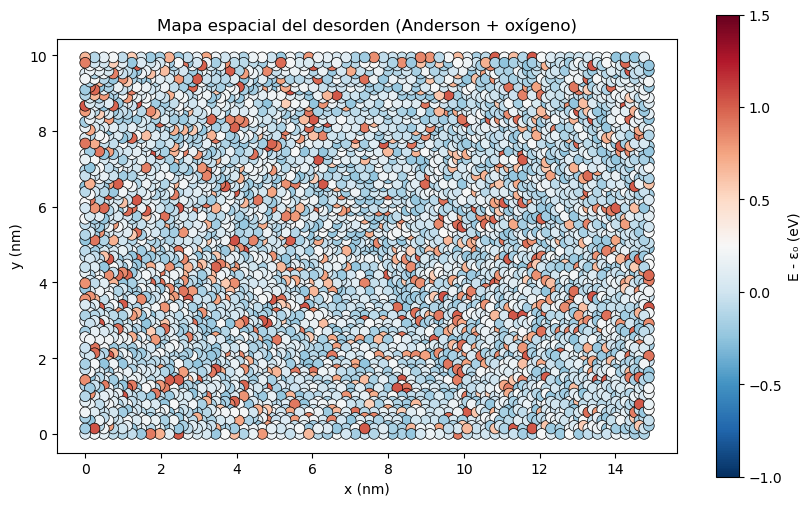

In [15]:
def plot_disorder_map(L=15, W=10):
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    syst = kwant.Builder()
    def shape(pos):
        x, y = pos
        return 0 <= x <= L and 0 <= y <= W
    
    # CORRECCIÓN
    syst[lat.shape(shape, (L/2, W/2))] = epsilon_0
    syst[lat.neighbors()] = -t1
    
    rng = np.random.RandomState(42)
    for site in syst.sites():
        # Mezcla de Anderson + oxígeno
        disorder = 0.5 * (rng.random() - 0.5)
        if rng.random() < 0.15:
            disorder += 0.8
        syst[site] += disorder
        
    # Dibujar
    fig, ax = plt.subplots(figsize=(10,6))
    positions = np.array([site.pos for site in syst.sites()])
    onsite = np.array([syst[site] - epsilon_0 for site in syst.sites()])
    sc = ax.scatter(positions[:,0], positions[:,1], c=onsite, cmap='RdBu_r',
                    s=60, edgecolors='k', linewidth=0.5, vmin=-1, vmax=1.5)
    plt.colorbar(sc, label='E - ε₀ (eV)')
    ax.set_aspect('equal')
    ax.set_title('Mapa espacial del desorden (Anderson + oxígeno)')
    ax.set_xlabel('x (nm)')
    ax.set_ylabel('y (nm)')
    plt.show()

plot_disorder_map()

Bibliografia

1. Gómez, E. V., Guarnizo, N. a. R., Perea, J. D., López, A. S., & Prías-Barragán, J. J. (2022). Exploring molecular and electronic property predictions of reduced graphene oxide nanoflakes via density functional theory. ACS Omega, 7(5), 3872–3880. https://doi.org/10.1021/acsomega.1c00963

2. Groth, C. W., Wimmer, M., Akhmerov, A. R., & Waintal, X. (2014). Kwant: a software package for quantum transport. New Journal of Physics, 16(6), 063065. https://doi.org/10.1088/1367-2630/16/6/063065

3. Lüth, H. (2015). Solid surfaces, interfaces and thin films (5th ed.). Springer.

4. Katsnelson, M. I. (2012). Graphene: Carbon in two dimensions. Cambridge University Press.

5. Katsnelson, M. I. (2012). Introduction to graphene. En Graphene: Carbon in two dimensions (pp. 1–24). World Scientific. https://doi.org/10.1142/9781848168350_0001

6. Roldán, R., Cappelluti, E., & Guinea, F. (2014). Interactions and superconductivity in heavily doped MoS₂. New Journal of Physics, 16(6), 063065. https://doi.org/10.1088/1367-2630/16/6/063065

7. Fang, S., Kuate Defo, R., Shirodkar, S. N., Lieu, S., Tritsaris, G. A., & Kaxiras, E. (2015). Ab initio tight-binding Hamiltonian for transition metal dichalcogenides. Nano-Micro Letters, 7(4), 376–381. https://doi.org/10.1007/s40820-014-0017-1

8. ETSF. (2024). Introduction to tight-binding. European Theoretical Spectroscopy Facility. https://etsf.polytechnique.fr/sites/default/files/2024-07/Introduction%20to%20Tight-Binding.pdf